### Deformation model Analys

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
%matplotlib widget

Constants and basic functions

In [74]:
rho = 10 #700 # kg/m^2, density of the wing
a=0.15 # m, span of the wing
b=0.04 # m, width of the wing
m= rho * a * b # mass of the wing

L=0.08
R=a/2

I_theta=4/3*R**2*m
I_alpha=m*R*L

c=0.08
k=0.5

alpha_0=22
f=4
Omega=2*np.pi*f

def alpha(t):
    return alpha_0*np.sin(Omega*t)

theta_0 = (I_alpha * alpha_0 * Omega**2) / np.sqrt(
        (k - I_theta * Omega**2)**2 + (c * Omega)**2
        )
phi = np.arctan2(c * Omega, k - I_theta * Omega**2)

def theta(t):
    return theta_0 * np.sin(Omega*t - phi)

def plot_theta_and_alpha():
    t = np.linspace(0, 1, 1000)

    plt.figure()

    plt.plot(t, alpha(t), label='alpha')
    plt.plot(t, theta(t), label='theta')
    
    plt.legend()
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (degrees)')
    plt.title('Alpha and Theta vs Time')
    plt.grid()
    
    plt.show()
    return

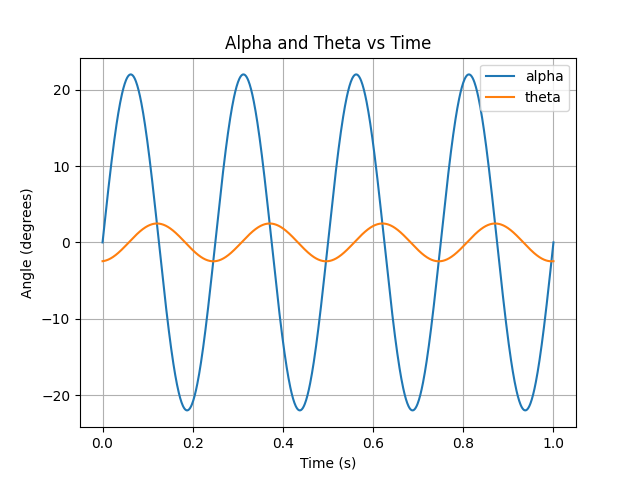

In [75]:
plot_theta_and_alpha()

Plot amplitude and phase of theta, function of k and c

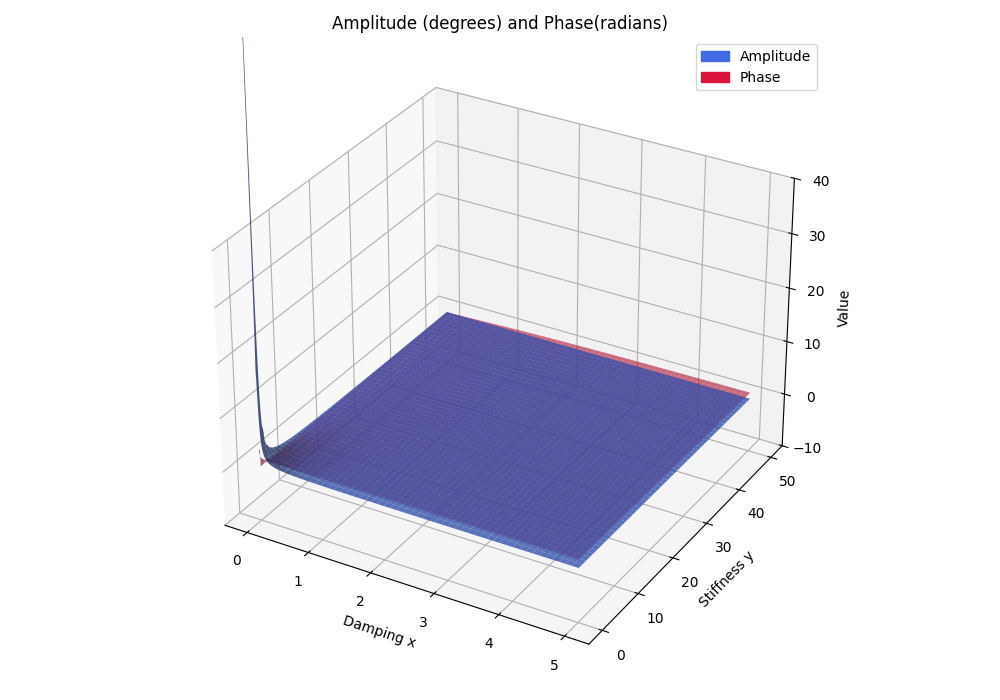

In [76]:
#c is x and k is y

def theta_amp(x,y):
    return (I_alpha * alpha_0 * Omega**2) / np.sqrt(
        (y - I_theta * Omega**2)**2 + (x * Omega)**2
        )

def theta_phase(x,y):
    return np.arctan2(x * Omega, y - I_theta * Omega**2)


x=np.linspace(0, 5, 1000)
y=np.linspace(0, 50, 1000)

X, Y = np.meshgrid(x, y)
Z_amp = theta_amp(X, Y)
Z_phase = theta_phase(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf_amp = ax.plot_surface(
    X, Y, Z_amp,
    color='royalblue',
    alpha=0.8
)

surf_phase = ax.plot_surface(
    X, Y, Z_phase,
    color='crimson',
    alpha=0.6
)

ax.set_title("Amplitude (degrees) and Phase(radians)")
ax.set_xlabel("Damping x")
ax.set_ylabel("Stiffness y")
ax.set_zlabel("Value")

ax.set_zlim(-10,40)

amp_patch = mpatches.Patch(color='royalblue', label='Amplitude')
phase_patch = mpatches.Patch(color='crimson', label='Phase')
ax.legend(handles=[amp_patch, phase_patch])

plt.tight_layout()
plt.show()


Lets study the phase

In [77]:
def plot_phase_and_intersection(phi=0):

    x = np.linspace(0, 1, 1000)
    y = np.linspace(0, 10, 1000)
    X, Y = np.meshgrid(x, y)

    Z_phase = theta_phase(X, Y)

    fig_tmp, ax_tmp = plt.subplots()
    contour_tmp = ax_tmp.contour(X, Y, Z_phase, levels=[phi])
    plt.close(fig_tmp)

    segments = contour_tmp.allsegs[0]

    x_all = []
    y_all = []

    for seg in segments:
        x_all.extend(seg[:, 0])
        y_all.extend(seg[:, 1])

    x_all = np.array(x_all)
    y_all = np.array(y_all)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(
        X, Y, Z_phase,
        color='crimson',
        alpha=0.6
    )

    Z_plane = np.full_like(X, phi)

    ax.plot_surface(
        X, Y, Z_plane,
        color='lightgreen',
        alpha=0.4
    )

    ax.plot(
        x_all,
        y_all,
        phi,
        color='black',
        linewidth=3,
        label="Intersection"
    )

    ax.set_title("Phase (radians)")
    ax.set_xlabel("Damping x")
    ax.set_ylabel("Stiffness y")
    ax.set_zlabel("Phase")

    phase_patch = mpatches.Patch(color='crimson', label='Phase surface')
    plane_patch = mpatches.Patch(color='lightgreen', label='Observed phase')
    ax.legend(handles=[phase_patch, plane_patch])

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,6))

    plt.plot(
        y_all,
        x_all,
        color='black',
        linewidth=2
    )

    plt.xlabel("Stiffness y")
    plt.ylabel("Damping x")
    plt.title(f"Intersection curve: phase = {phi} rad")

    plt.grid()
    plt.show()

    return x_all, y_all


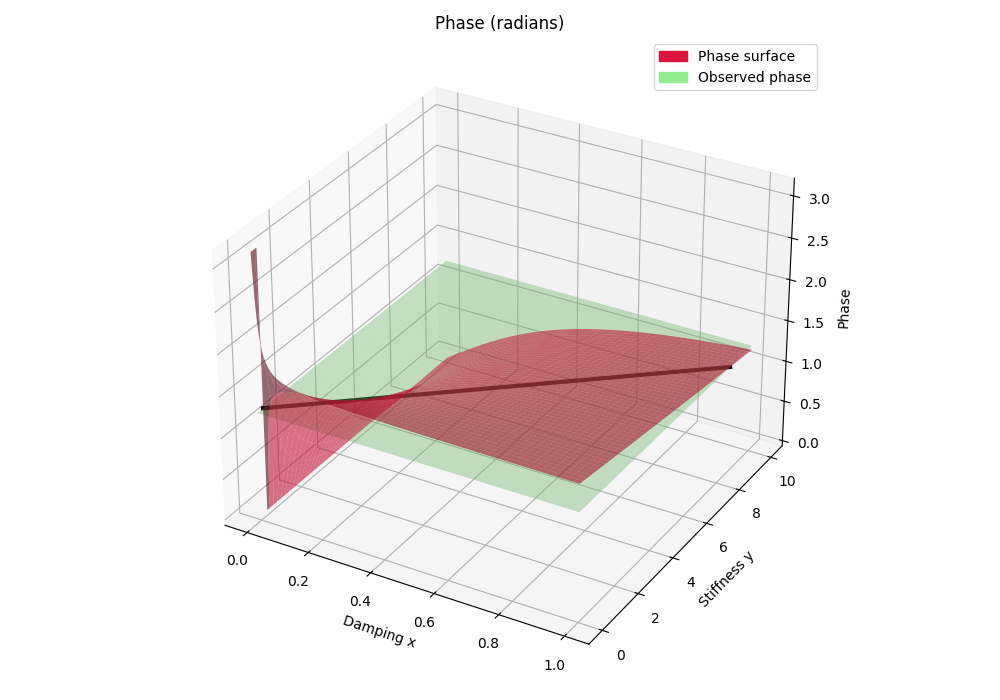

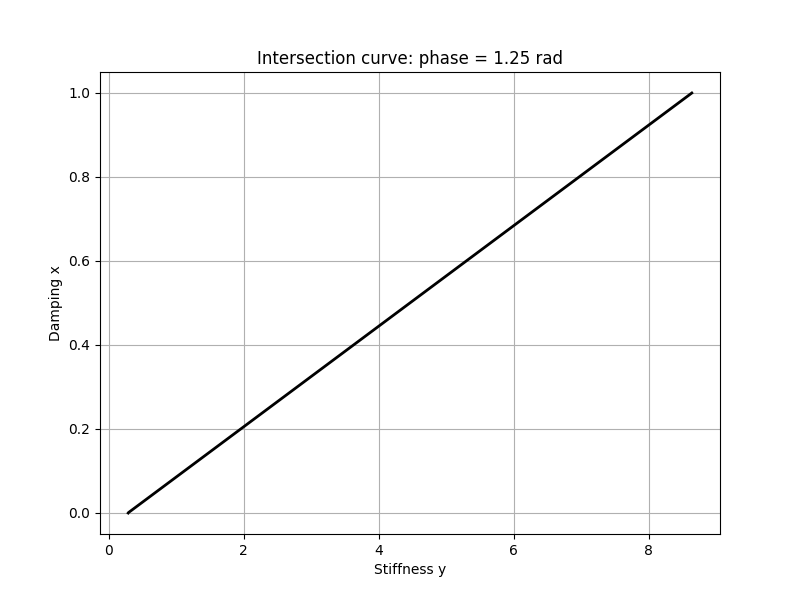

In [78]:
x_phase,y_phase = plot_phase_and_intersection(1.25)

In [79]:
def plot_amp_and_intersection(x_phase, y_phase, amp_target):

    x_min, x_max = x_phase.min(), x_phase.max()
    y_min, y_max = y_phase.min(), y_phase.max()

    x = np.linspace(x_min, x_max, 1000)
    y = np.linspace(y_min, y_max, 1000)

    X, Y = np.meshgrid(x, y)

    Z_amp = theta_amp(X, Y)

    fig_tmp, ax_tmp = plt.subplots()
    contour_tmp = ax_tmp.contour(X, Y, Z_amp, levels=[amp_target])
    plt.close(fig_tmp)

    segments = contour_tmp.allsegs[0]

    x_amp = []
    y_amp = []

    for seg in segments:
        x_amp.extend(seg[:, 0])
        y_amp.extend(seg[:, 1])

    x_amp = np.array(x_amp)
    y_amp = np.array(y_amp)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        X, Y, Z_amp,
        color='blue',
        alpha=0.7
    )

    Z_plane = np.full_like(X, amp_target)

    ax.plot_surface(
        X, Y, Z_plane,
        color='orange',
        alpha=0.4
    )

    ax.plot(
        x_amp,
        y_amp,
        amp_target*np.ones_like(x_amp),
        color='blue',
        linewidth=3
    )



    ax.set_xlabel("Damping x")
    ax.set_ylabel("Stiffness y")
    ax.set_zlabel("Amplitude (degrees)")
    ax.set_zlim(0, 40)

    plt.show()

    plt.figure(figsize=(8,6))

    plt.plot(
        y_phase,
        x_phase,
        color='red',
        linewidth=2,
        label="Possible (x,y) from phase"
    )

    plt.plot(
        y_amp,
        x_amp,
        color='blue',
        linewidth=2,
        label="Possible (x,y) from amplitude"
    )

    plt.xlabel("Stiffness y")
    plt.ylabel("Damping x")
    plt.title("Possible parameter pairs (x,y)")

    plt.legend()
    plt.grid()
    plt.show()

    return x_amp, y_amp


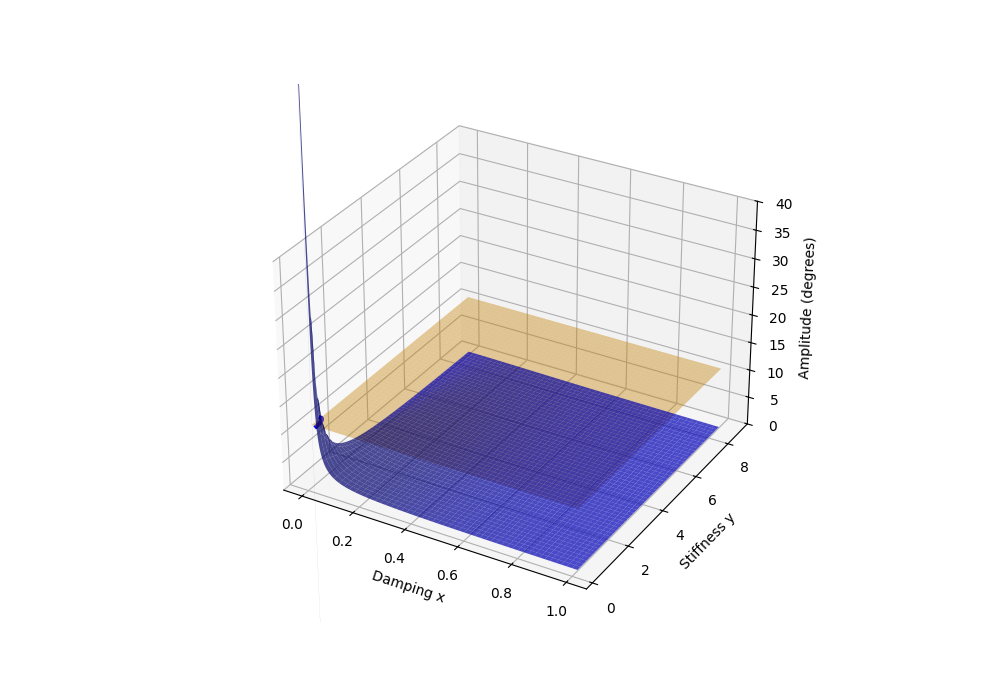

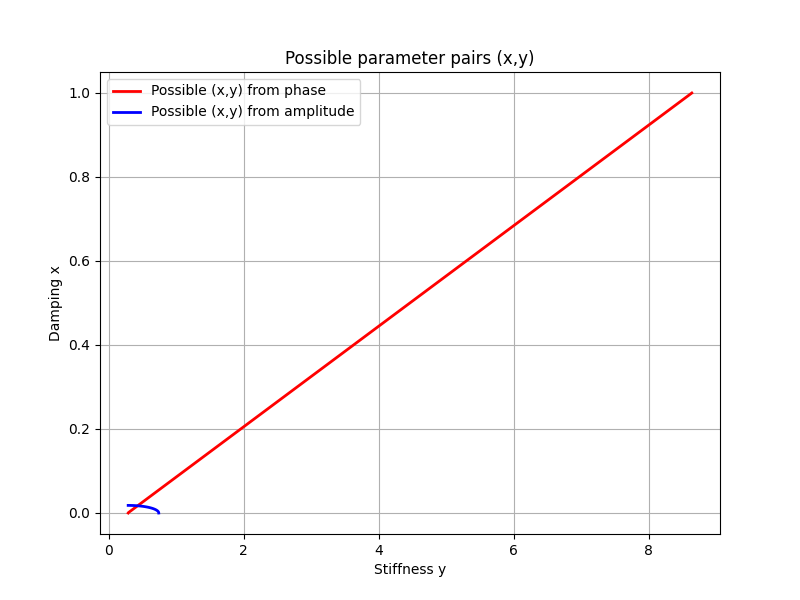

In [80]:
x_amp, y_amp = plot_amp_and_intersection(x_phase, y_phase, amp_target=11)